# import libraries

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Libraries imported successfully")

Libraries imported successfully


# Load dataset

In [6]:
data_dir = "../data/archive (1)"

In [7]:
classes = os.listdir(data_dir)
classes

['Hazardous', 'Non-Recyclable', 'Organic', 'Recyclable']

### Data Augmentation and Normalization

In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

### Loading Training Dataset

In [9]:
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 2309 images belonging to 4 classes.


### Loading the Validation Dataset

In [10]:
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 575 images belonging to 4 classes.


### Check Class Indices

In [11]:
train_data.class_indices

{'Hazardous': 0, 'Non-Recyclable': 1, 'Organic': 2, 'Recyclable': 3}

### Visualise Dataset

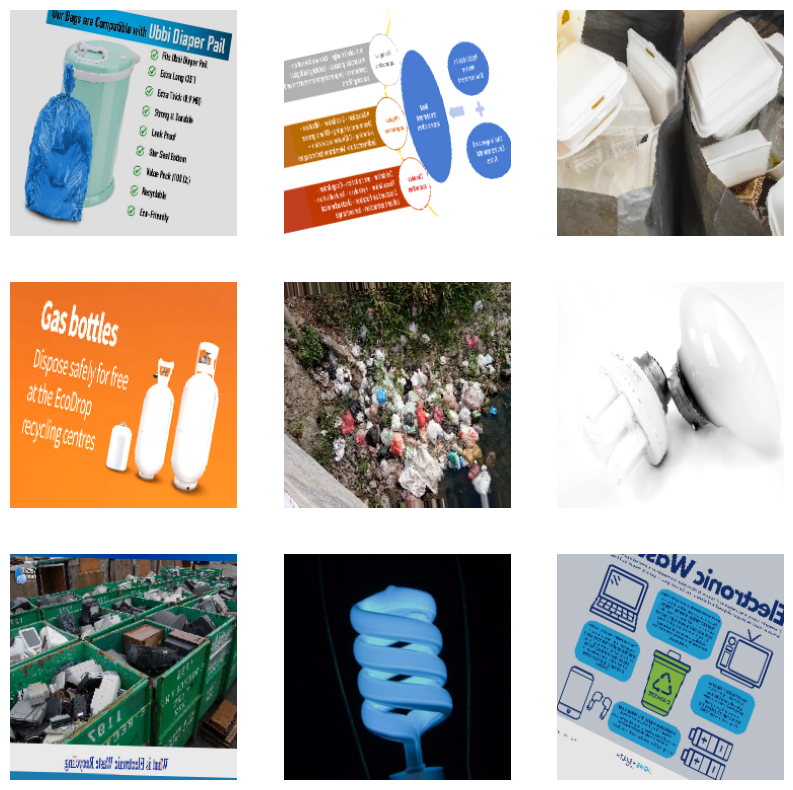

In [12]:
images,labels = next(train_data)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

### Build ANN Model Architecture

In [13]:
# Sequential model define karna aur layers add karna
ann_model = Sequential([
    Flatten(input_shape=(224, 224, 3)),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

C:\Users\prime\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Compilation

In [14]:
# compile model with optimizer and loss function
ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Check Architecture Summary

In [15]:
# check compplete snapshot of model
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,203,204 (294.51 MB)

 Trainable params: 77,203,204 (294.51 MB)

 Non-trainable params: 0 (0.00 B)

### Train ANN Model

In [16]:
# model training process start
ann_history = ann_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
15/73 ━━━━━━━━━━━━━━━━━━━━ 3:46 4s/step - accuracy: 0.2495 - loss: 113.7264

C:\Users\prime\AppData\Roaming\Python\Python313\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


16/73 ━━━━━━━━━━━━━━━━━━━━ 3:37 4s/step - accuracy: 0.2487 - loss: 113.8547

C:\Users\prime\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


73/73 ━━━━━━━━━━━━━━━━━━━━ 366s 5s/step - accuracy: 0.2560 - loss: 36.9886 - val_accuracy: 0.3235 - val_loss: 1.3851
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.3188 - loss: 1.5506 - val_accuracy: 0.3200 - val_loss: 1.3757
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 225s 3s/step - accuracy: 0.3214 - loss: 1.5020 - val_accuracy: 0.3183 - val_loss: 1.3720
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.3235 - loss: 1.3785 - val_accuracy: 0.3235 - val_loss: 1.3694
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.3227 - loss: 1.3733 - val_accuracy: 0.3235 - val_loss: 1.3741
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.3231 - loss: 1.3829 - val_accuracy: 0.3235 - val_loss: 1.3729
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.3227 - loss: 1.3732 - val_accuracy: 0.3235 - val_loss: 1.3731
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.3231 - loss: 1.3727 - val_accuracy: 0.3252 - val_loss: 1

### Save Train Model

In [17]:
# save trained model to directory with weight
ann_model.save("../models/ann_model.h5")
print("✅ ANN Model trained and saved successfully inside the models folder!")

✅ ANN Model trained and saved successfully inside the models folder!


### Build CNN Model Architecture

In [18]:
cnn_model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    # Flattening section
    Flatten(),
    # Fully Connected Dense Layers
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    # Final Output Layer (4 waste categories)
    Dense(4, activation='softmax')
])

C:\Users\prime\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile CNN Model

In [19]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### CNN Blueprint verification

In [20]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,804 (91.20 MB)

 Trainable params: 23,908,356 (91.20 MB)

 Non-trainable params: 448 (1.75 KB)

### Training the CNN Model

In [21]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 344s 5s/step - accuracy: 0.3257 - loss: 2.0160 - val_accuracy: 0.2261 - val_loss: 4.1659
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 338s 5s/step - accuracy: 0.3534 - loss: 1.6389 - val_accuracy: 0.2261 - val_loss: 8.0041
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 285s 4s/step - accuracy: 0.3963 - loss: 1.5220 - val_accuracy: 0.2243 - val_loss: 8.9689
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 291s 4s/step - accuracy: 0.3824 - loss: 1.4868 - val_accuracy: 0.2226 - val_loss: 10.0297
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 299s 4s/step - accuracy: 0.4023 - loss: 1.4190 - val_accuracy: 0.2209 - val_loss: 5.7398
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 383s 5s/step - accuracy: 0.4006 - loss: 1.3890 - val_accuracy: 0.2400 - val_loss: 2.1236
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 279s 4s/step - accuracy: 0.4292 - loss: 1.3405 - val_accuracy: 0.2522 - val_loss: 1.6667
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.4353 - loss: 1.2865 - val_accuracy: 0.2417 - 

### Save the trained CNN Model

In [22]:
# save the trained cnnmodelto directory
cnn_model.save("../models/cnn_model.h5")
print("✅ CNN Model trained and saved successfully inside the models folder!")

✅ CNN Model trained and saved successfully inside the models folder!


### Check Performance Evaluation & Trend Analysis of Both Models ANN &  CNN

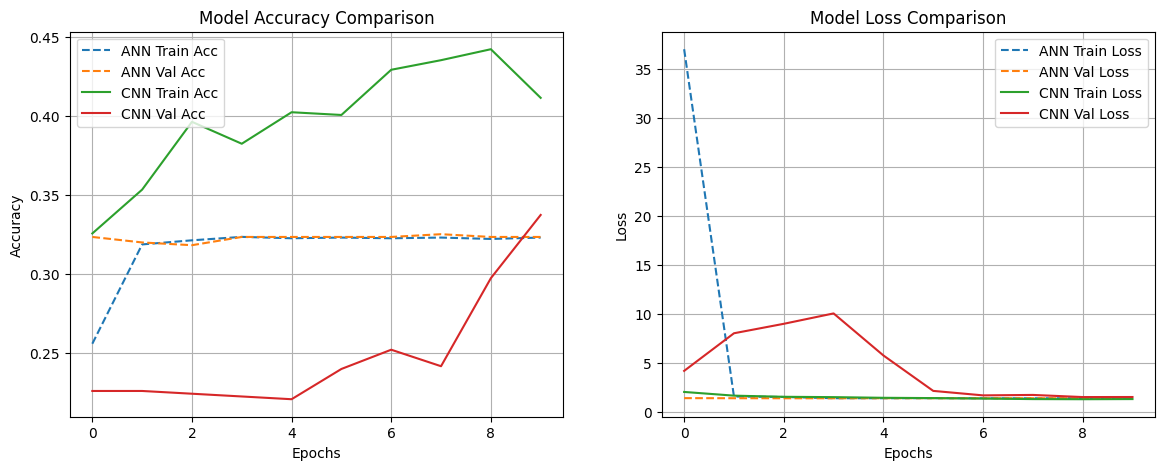

In [23]:
import matplotlib.pyplot as plt
# make subplots for accuracy and loss graph
plt.figure(figsize=(14, 5))
# 1. Accuracy Comparison Graph
plt.subplot(1, 2, 1)
plt.plot(ann_history.history['accuracy'], label='ANN Train Acc', linestyle='--')
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc', linestyle='--')
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
# 2. Loss Comparison Graph
plt.subplot(1, 2, 2)
plt.plot(ann_history.history['loss'], label='ANN Train Loss', linestyle='--')
plt.plot(ann_history.history['val_loss'], label='ANN Val Loss', linestyle='--')
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('Model Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Train CNN with Callbacks

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3
)

### Advance CNN Trainig with Callbacks

In [25]:
# use model traning loop with callbacks
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)
# save optimized model weight to directory
cnn_model.save("../models/cnn_model.h5")
print("✅ Advanced CNN Model trained with callbacks and saved successfully!")

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 369s 5s/step - accuracy: 0.4253 - loss: 1.2674 - val_accuracy: 0.3617 - val_loss: 1.3409 - learning_rate: 0.0010
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 521s 7s/step - accuracy: 0.4383 - loss: 1.2405 - val_accuracy: 0.3061 - val_loss: 1.3857 - learning_rate: 0.0010
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 1775s 25s/step - accuracy: 0.4275 - loss: 1.2349 - val_accuracy: 0.3304 - val_loss: 1.3834 - learning_rate: 0.0010
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 333s 5s/step - accuracy: 0.4725 - loss: 1.1988 - val_accuracy: 0.3043 - val_loss: 1.5463 - learning_rate: 0.0010
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 2004s 28s/step - accuracy: 0.4721 - loss: 1.1756 - val_accuracy: 0.3548 - val_loss: 1.4439 - learning_rate: 2.0000e-04
Epoch 6/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 361s 5s/step - accuracy: 0.4768 - loss: 1.1858 - val_accuracy: 0.3443 - val_loss: 1.3843 - learning_rate: 2.0000e-04


✅ Advanced CNN Model trained with callbacks and saved successfully!


### Advance CNN performance visualisation

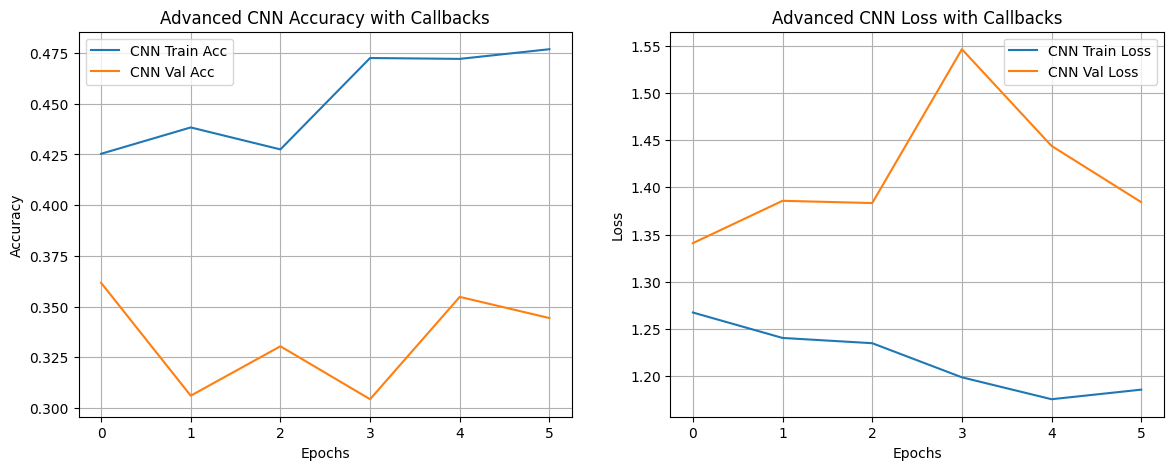

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
# 1. Advanced CNN Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('Advanced CNN Accuracy with Callbacks')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
# 2. Advanced CNN Loss Graph
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('Advanced CNN Loss with Callbacks')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Advance CNN Model Evaluation

In [27]:
# check final loss or accuracy on validation dataset
loss, accuracy = cnn_model.evaluate(val_data)
print("Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 985ms/step - accuracy: 0.3704 - loss: 1.3338
Accuracy: 0.37043479084968567


### Make detailed classification Report

In [28]:
from sklearn.metrics import classification_report
import numpy as np
# 1. Generate predictions for the validation dataset
pred = cnn_model.predict(val_data)
# 2. Extract the highest probability index for each prediction
pred_classes = np.argmax(pred, axis=1)
# 3. Retrieve the original ground truth labels from the validation dataset
true_classes = val_data.classes
# 4. Print the comprehensive classification metrics table
print(classification_report(true_classes, pred_classes))

18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 995ms/step
              precision    recall  f1-score   support

           0       0.33      0.56      0.41       186
           1       0.23      0.16      0.19       128
           2       0.38      0.15      0.21       131
           3       0.29      0.27      0.28       130

    accuracy                           0.31       575
   macro avg       0.31      0.28      0.27       575
weighted avg       0.31      0.31      0.29       575



### Confusion Matrix Heatmap

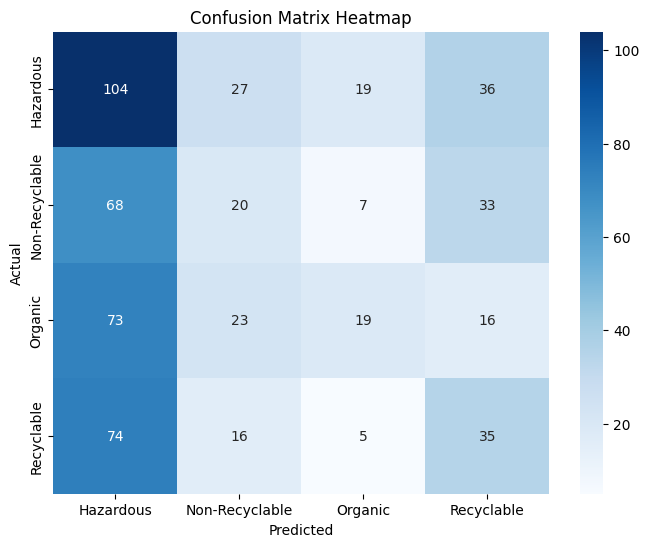

In [29]:
from sklearn.metrics import confusion_matrix
# 1. Compute the raw structural confusion matrix values
cm = confusion_matrix(true_classes, pred_classes)
# 2. Fetch target class names from the dataset generator dictionary keys
classes = list(val_data.class_indices.keys())
# 3. Configure the plotting canvas size
plt.figure(figsize=(8, 6))
# 4. Generate the structured heatmap visualization layout
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    xticklabels=classes, 
    yticklabels=classes,
    cmap='Blues'
)
# 5. Attach structural metadata titles and label axes
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Plotting the accuracy Graph

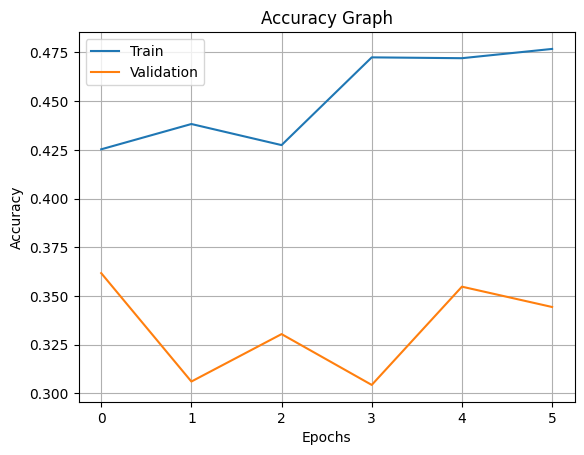

In [30]:
# Plot training and validation accuracy over training epochs
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
# Add labels, legend descriptions, and title configurations
plt.legend(["Train", "Validation"])
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
# Display the finalized accuracy visual trend layout
plt.show()

### Plotting the Loss Graph

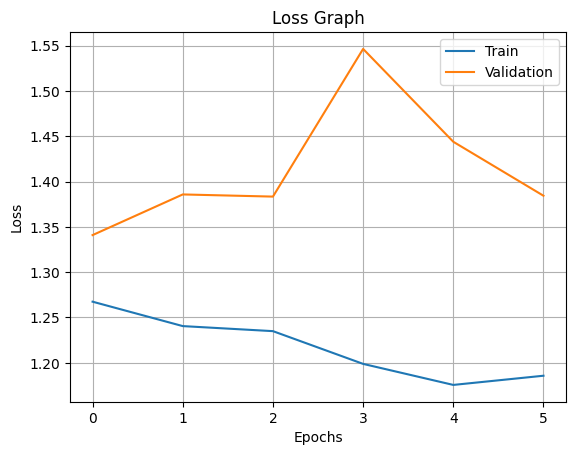

In [31]:
# Plot training and validation categorical loss curves
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
# Add structural metadata configuration properties
plt.legend(["Train", "Validation"])
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
# Render the distinct standalone loss canvas mapping
plt.show()